# FashionMNIST Classification using Neural Networks - Homework Assignment

![Pix2Pix Architecture](https://i.imgur.com/a3uAqnb.png)

In this homework, you will implement a **Neural Network classifier** for the FashionMNIST dataset. This dataset contains grayscale images of 28x28 pixels representing 10 categories of clothing items.

## 📌 Project Overview
- **Task**: Multi-class classification of clothing items
- **Dataset**: FashionMNIST (10 classes of clothing)
- **Architecture**: Fully connected neural network or CNN
- **Goal**: Achieve high accuracy on fashion item classification

## 📚 Learning Objectives
By completing this assignment, you will:
- Understand image classification with neural networks
- Implement data preprocessing and augmentation
- Build and train neural network architectures
- Evaluate model performance and visualize results
- Practice PyTorch fundamentals

## 1️⃣ Import Libraries and Configuration

**Task**: Import all necessary libraries and set up configuration parameters.

**Requirements**:
- Import PyTorch, torchvision, and related libraries
- Import matplotlib, numpy, and other utilities
- Set random seeds for reproducibility
- Configure hyperparameters with reasonable values

In [5]:
# TODO: Import all necessary libraries
# torch, torch.nn, torch.optim
import torch
import torch.nn as nn
import torch.optim as optim

# torchvision.datasets, torchvision.transforms
import torchvision
import torchvision.datasets as datasets
import torchvision.transforms as transforms

# matplotlib.pyplot, numpy
import matplotlib.pyplot as plt
import numpy as np

# ADD
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Set random seeds for reproducibility
# TODO: Set random seeds for reproducibility (use seed=42)
seed = 42
# CPU
torch.manual_seed(seed)
np.random.seed(seed)
# GPU
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

# TODO: Check device availability and print
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

# TODO: Define configuration parameters:
IMG_SIZE = 28  # Image size (28x28 for FashionMNIST)
BATCH_SIZE = 64  # Batch size
LEARNING_RATE = 0.001  # Learning rate
NUM_EPOCHS = 10  # Number of training epochs
NUM_CLASSES = 10  # Number of clothing categories

Using device: cuda


## 2️⃣ Data Loading and Preprocessing

**Task**: Load the FashionMNIST dataset and apply appropriate transformations.

**Requirements**:
- Load train and test datasets from torchvision
- Apply normalization and data augmentation
- Create data loaders with appropriate batch sizes
- Visualize sample images with labels

100%|██████████| 26.4M/26.4M [00:02<00:00, 10.5MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 163kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.08MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 23.3MB/s]


Train dataset size: 60000
Test dataset size: 10000
Class names: ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


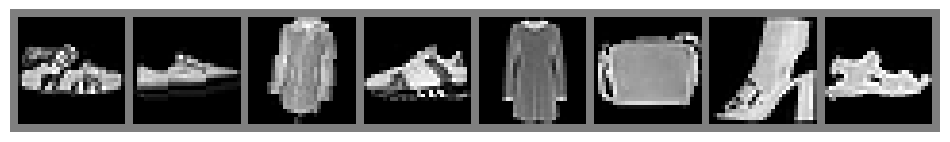

Labels: ['Sandal', 'Sneaker', 'Coat', 'Sneaker', 'Dress', 'Bag', 'Ankle boot', 'Sandal']


In [6]:
# TODO: Define transforms using transforms.Compose:
#       For training use any of: RandomRotation, RandomHorizontalFlip, Other Data Augmentation,
#       Fot training must use: ToTensor, Normalize
#       For testing: ToTensor, Normalize
#       Use mean=0.5, std=0.5 for normalization to get [-1,1] range
# train
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10), # from -10 to 10
    transforms.ToTensor(), # convert to pytorch tensor
    transforms.Normalize((0.5,), (0.5,)) # only one channel for gray pictures
    # mean + std
])

# test
test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# TODO: Load FashionMNIST datasets:
# Fixed: Added 'root' argument to specify data directory
train_data = datasets.FashionMNIST(root='./data', download=True, train=True, transform=train_transform)
test_data = datasets.FashionMNIST(root='./data', download=True, train=False, transform=test_transform)

# TODO: Create train_loader and test_loader with DataLoader
#       Use appropriate batch_size and shuffle settings
train_loader = torch.utils.data.DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True) # avoid remembering the sequence
test_loader = torch.utils.data.DataLoader(test_data, batch_size=BATCH_SIZE, shuffle=False)


# TODO: Print dataset sizes and class names
print(f'Train dataset size: {len(train_data)}')
print(f'Test dataset size: {len(test_data)}')
print(f'Class names: {train_data.classes}')

# TODO: Visualize a batch of training images with their labels
def imshow(img):
    img = img * 0.5 + 0.5  # antinormalization
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0))) # 0: C  1: H  2: W    pytorch --> matplotlib
    plt.axis('off')
    plt.show()

# get a batch
dataiter = iter(train_loader)
images, labels = next(dataiter)

# show first 8 images in a row
plt.figure(figsize=(12, 4))
imshow(torchvision.utils.make_grid(images[:8])) # select first 8 pictures
print('Labels:', [train_data.classes[l] for l in labels[:8]]) # convert code to actual class

## 3️⃣ Model Architecture

**Task**: Implement a neural network classifier for FashionMNIST.

**Requirements**:
- Choose between fully connected network or CNN
- Use appropriate activation functions and regularization
- Ensure output matches number of classes (10)
- Initialize the model and move to device

In [7]:
'''
  test both, use FCN as baseline
'''

# TODO: Create a classifier class inheriting from nn.Module

# Fully Connected Network
# TODO: In __init__:
#       - Flatten layer: nn.Flatten()
#       - Hidden layers: nn.Linear(784, 512) + ReLU + Dropout
#       - More hidden layers as needed
#       - Output layer: nn.Linear(hidden_size, 10)
# -------------------------------------------------------------------------
class FCNClassifier(nn.Module): # inherent from nn.Module
    def __init__(self):
        super(FCNClassifier, self).__init__()
        self.flatten = nn.Flatten() # 28*28 --> 1*784
        self.layers = nn.Sequential( # combine all the layers sequentially
            nn.Linear(28 * 28, 512),
            nn.ReLU(),
            nn.Dropout(0.2), # dropout_layer: avoid overfitting; 0.2: 20% shut down
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, 10)
            # no softmax, softmax in nn.CrossEntropyLoss()
        )

    def forward(self, x):
        x = self.flatten(x)
        return self.layers(x)

# If you know what a Convolutional Neural Network is, use this instead,
# TODO: In __init__:
#       - Conv layers: nn.Conv2d + ReLU + MaxPool2d
#       - Multiple conv blocks for feature extraction
#       - Flatten and fully connected layers for classification
#       - Output layer with 10 units
# -------------------------------------------------------------------------
class CNNClassifier(nn.Module):
    def __init__(self):
        super(CNNClassifier, self).__init__()
        # feature extraction part
        self.features = nn.Sequential(
            # 1st conv layer
            nn.Conv2d(1, 32, kernel_size=3, padding=1), # input: 1 channel; output: 32 feature maps; padding to keep size
            nn.ReLU(),
            nn.MaxPool2d(2, 2), # kernal size: 2*2; stride: 2 therefore, 28*28 --> 14*14

            #2nd conv layer
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2) # 14*14 --> 7*7
        )

        # classification part
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

# TODO: Implement forward(self, x) method
'''
  already implemented above in respective classes
'''

# TODO: Initialize model and move to device
MODEL_TYPE = 'CNN' # options: 'FCN' or 'CNN'

if MODEL_TYPE == 'CNN':
    model = CNNClassifier().to(device) # to GPU
else:
    model = FCNClassifier().to(device)

# TODO: Print model architecture and parameter count
print(model) # print the structure
total_params = sum(p.numel() for p in model.parameters())
print(f'Total parameters: {total_params}')

# TODO: Test with random input to verify output shape
test_input = torch.randn(1, 1, 28, 28).to(device) # num = 1; C = 1; H = 28; W = 28
with torch.no_grad(): # only test, no grad needed
    output = model(test_input)
print(f'Output shape: {output.shape}') # expected: [1, 10]


CNNClassifier(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3136, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=10, bias=True)
  )
)
Total parameters: 421642
Output shape: torch.Size([1, 10])


## 4️⃣ Loss Function and Optimizer

**Task**: Set up loss function and optimizer for training.

**Requirements**:
- Use appropriate loss function for multi-class classification
- Initialize optimizer with given hyperparameters
- Optional: Add learning rate scheduler


In [8]:
# TODO: Define loss function:
#       criterion = nn.CrossEntropyLoss() for multi-class classification
criterion = nn.CrossEntropyLoss() # softmax here

# TODO: Create optimizer:
#       optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
#       or torch.optim.SGD with momentum
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
# optimizer = torch.optim.SGD(model.parameters(), lr=LEARNING_RATE, momentum=0.9)

## 5️⃣ Training Function

**Task**: Implement the training function with proper loss tracking.

**Requirements**:
- Train model for specified number of epochs
- Track training loss and accuracy
- Display progress during training
- Save loss values for plotting

In [9]:
# TODO: Create training function:
def train_model(model, train_loader, criterion, optimizer, num_epochs, device):
    # Define learning rate scheduler
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)

# TODO: Initialize lists to store losses and accuracies
    history = {'loss': [], 'accuracy': []}

# TODO: For each epoch:
    for epoch in range(num_epochs):
#       - Set model to training mode
        model.train()
#       - Initialize running loss and correct predictions
        running_loss = 0.0
        correct = 0
        total = 0

#       For each batch:
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device) # Move to GPU
#       - Zero gradients
            optimizer.zero_grad()
#       - Forward pass:
            outputs = model(images)
#       - Calculate loss:
            loss = criterion(outputs, labels)
#       - Backward pass:
            loss.backward()
#       - Update weights:
            optimizer.step()
#       - Track statistics
            running_loss += loss.item() * images.size(0) # crossentropy --> mean loss
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

# TODO: Calculate and print epoch statistics (loss, accuracy)
        # Calculate statistics for the current epoch
        epoch_loss = running_loss / len(train_loader.dataset)
        epoch_acc = 100 * correct / total

        # Append to history for plotting
        history['loss'].append(epoch_loss)
        history['accuracy'].append(epoch_acc)

        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss:.4f}, Accuracy: {epoch_acc:.2f}%')

# TODO: Optional: Update learning rate with scheduler
        scheduler.step() # adaptive learning rate

# TODO: Return training history for plotting
    return history

## 6️⃣ Training Loop

**Task**: Execute the training process and monitor progress.

**Requirements**:
- Run training for the specified number of epochs
- Display training progress
- Track loss reduction over time


In [10]:
# TODO: Call training function and store results
train_history = train_model(
    model = model,
    train_loader = train_loader,
    criterion = criterion,
    optimizer = optimizer,
    num_epochs = NUM_EPOCHS,
    device = device
)

# TODO: Print training completion message
print("Training Complete!")

# TODO: Display final training statistics
final_loss = train_history['loss'][-1]
final_acc = train_history['accuracy'][-1]
print(f"Final Loss: {final_loss:.4f}")
print(f"Final Accuracy: {final_acc:.2f}%")

Epoch [1/10], Loss: 0.5109, Accuracy: 81.60%
Epoch [2/10], Loss: 0.3457, Accuracy: 87.27%
Epoch [3/10], Loss: 0.3003, Accuracy: 88.87%
Epoch [4/10], Loss: 0.2710, Accuracy: 90.11%
Epoch [5/10], Loss: 0.2532, Accuracy: 90.56%
Epoch [6/10], Loss: 0.2114, Accuracy: 92.23%
Epoch [7/10], Loss: 0.2027, Accuracy: 92.65%
Epoch [8/10], Loss: 0.1986, Accuracy: 92.73%
Epoch [9/10], Loss: 0.1948, Accuracy: 92.80%
Epoch [10/10], Loss: 0.1935, Accuracy: 92.90%
Training Complete!
Final Loss: 0.1935
Final Accuracy: 92.90%



## 7️⃣ Model Evaluation

**Task**: Evaluate the trained model on test data.

**Requirements**:
- Calculate test accuracy and loss
- Generate classification report
- Create confusion matrix
- Analyze per-class performance

Test Loss: 0.2316, Test Accuracy: 91.86%

Classification Report:
              precision    recall  f1-score   support

 T-shirt/top       0.85      0.90      0.88      1000
     Trouser       0.99      0.99      0.99      1000
    Pullover       0.84      0.91      0.87      1000
       Dress       0.91      0.93      0.92      1000
        Coat       0.89      0.84      0.87      1000
      Sandal       0.99      0.97      0.98      1000
       Shirt       0.82      0.72      0.77      1000
     Sneaker       0.93      0.99      0.96      1000
         Bag       0.99      0.98      0.98      1000
  Ankle boot       0.98      0.95      0.97      1000

    accuracy                           0.92     10000
   macro avg       0.92      0.92      0.92     10000
weighted avg       0.92      0.92      0.92     10000



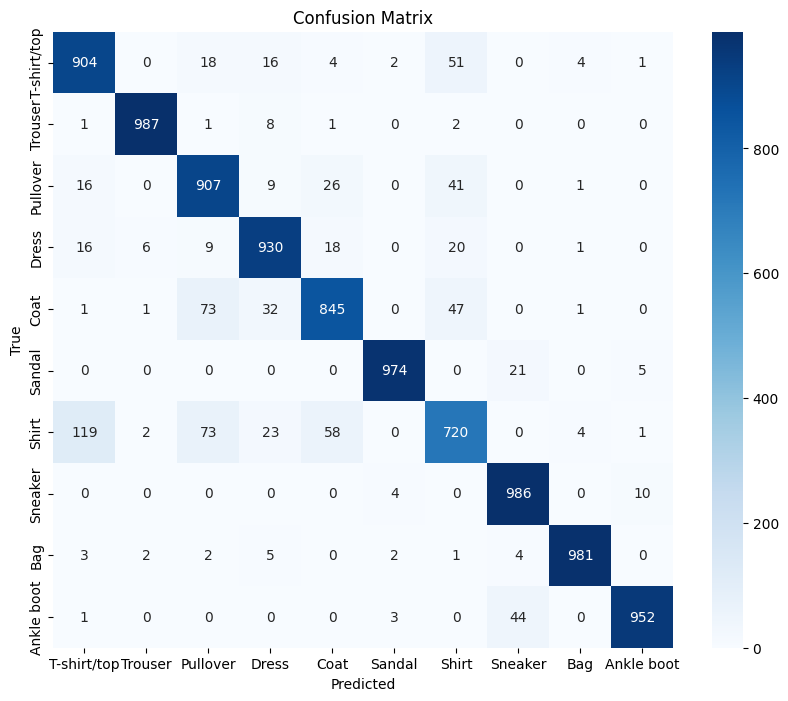


Per-class Accuracies:
T-shirt/top : 90.40%
Trouser     : 98.70%
Pullover    : 90.70%
Dress       : 93.00%
Coat        : 84.50%
Sandal      : 97.40%
Shirt       : 72.00%
Sneaker     : 98.60%
Bag         : 98.10%
Ankle boot  : 95.20%


In [11]:
# TODO: Create evaluation function:
def evaluate_model(model, test_loader, device):

# TODO: Set model to evaluation mode
    model.eval()

# TODO: Initialize test loss and accuracy tracking
    test_loss = 0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []

# TODO:
    with torch.no_grad():
#       For each test batch:
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
#       - Forward pass
            outputs = model(images)

#       - Calculate loss and predictions
            loss = criterion(outputs, labels)
            test_loss += loss.item() * images.size(0)

            _, predicted = torch.max(outputs.data, 1)

#       - Track correct predictions
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

# collect all predictions and tags
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())


# TODO: Calculate overall test accuracy and loss
    avg_loss = test_loss / len(test_loader.dataset)
    accuracy = 100 * correct / total

    print(f'Test Loss: {avg_loss:.4f}, Test Accuracy: {accuracy:.2f}%')
    return all_labels, all_preds

# call the func
labels, preds = evaluate_model(model, test_loader, device)

# TODO: Generate detailed classification report using sklearn
# from sklearn.metrics import classification_report, confusion_matrix
print("\nClassification Report:")
print(classification_report(labels, preds, target_names=test_data.classes))

# TODO: Create and plot confusion matrix
# import seaborn as sns
cm = confusion_matrix(labels, preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=test_data.classes, yticklabels=test_data.classes)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# TODO: Print per-class accuracies
class_accuracies = 100 * cm.diagonal() / cm.sum(axis=1)

print("\nPer-class Accuracies:")
# traverse and print accuracy for each class
for i, class_name in enumerate(test_data.classes):
    print(f"{class_name:<12}: {class_accuracies[i]:.2f}%")

## 8️⃣ Results Visualization

**Task**: Create visualizations to analyze model performance.

**Requirements**:
- Plot training loss curves
- Show sample predictions with confidence
- Visualize misclassified examples
- Display model predictions on test images

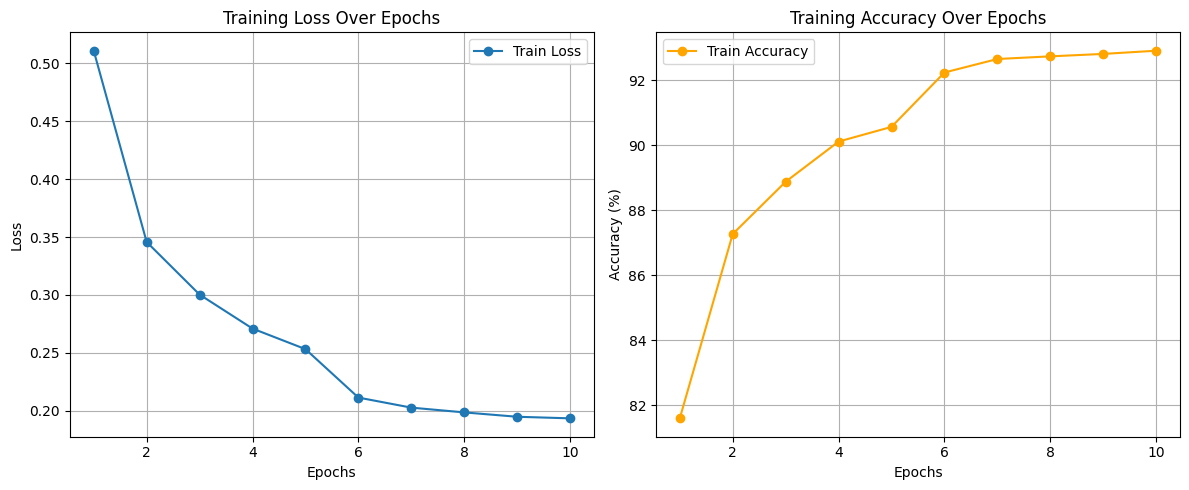

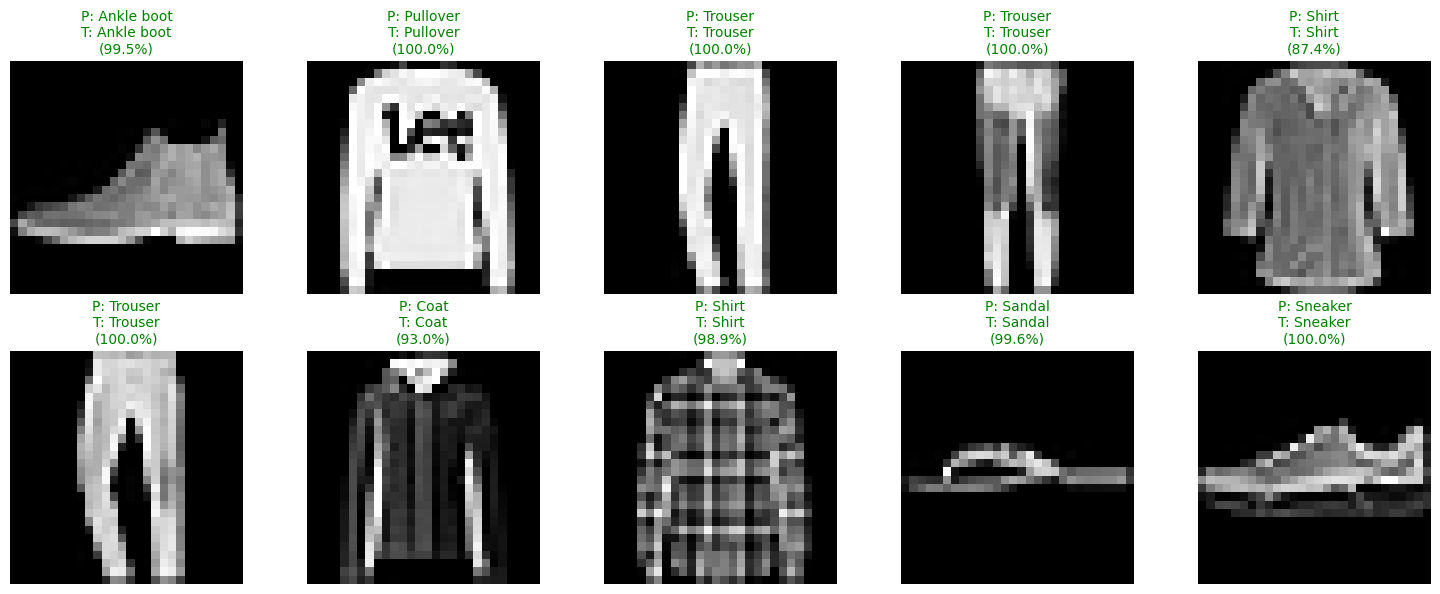

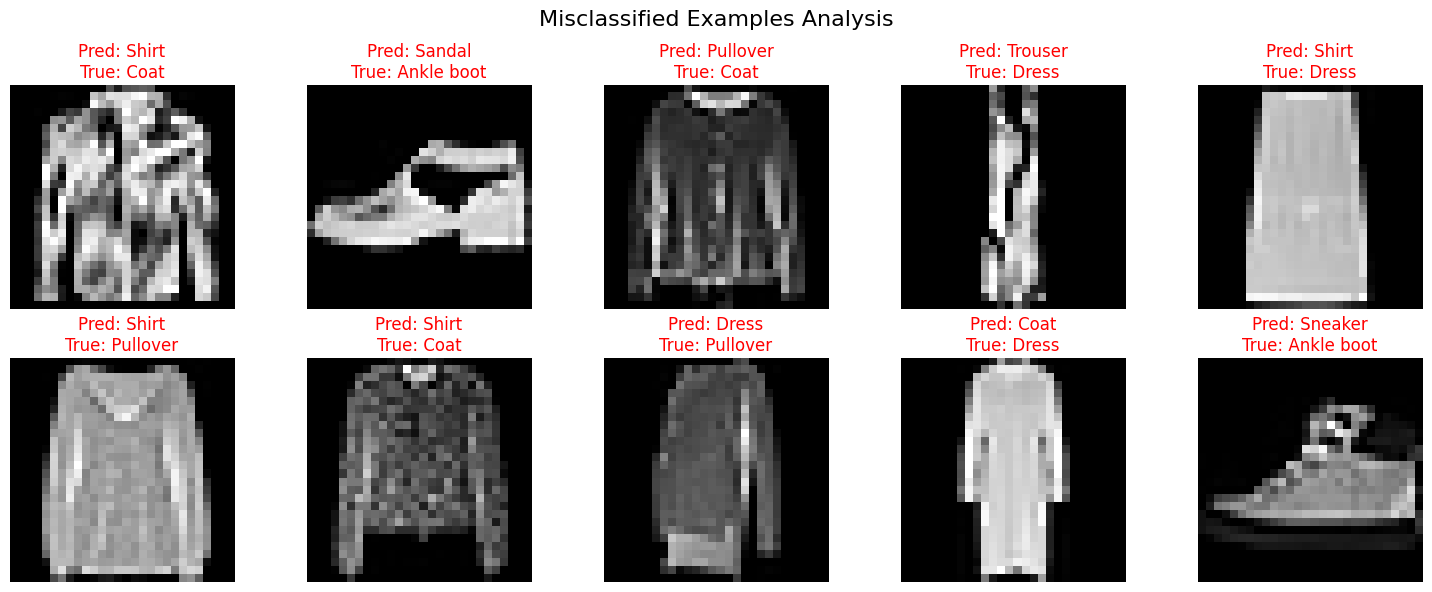

In [12]:
# TODO: Plot training loss and accuracy curves over epochs
plt.figure(figsize=(12, 5))

# 1. Loss curve
plt.subplot(1, 2, 1)
plt.plot(range(1, len(train_history['loss']) + 1), train_history['loss'], marker='o', label='Train Loss')
plt.title('Training Loss Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()

# 2. Accuracy curve
plt.subplot(1, 2, 2)
plt.plot(range(1, len(train_history['accuracy']) + 1), train_history['accuracy'], marker='o', color='orange', label='Train Accuracy')
plt.title('Training Accuracy Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

# TODO: Create function to show sample predictions:
def visualize_predictions(model, test_loader, device, num_images=10):
    model.eval()
    # Get a batch of test samples
    images, labels = next(iter(test_loader))
    images, labels = images.to(device), labels.to(device)

    with torch.no_grad():
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        probs = torch.nn.functional.softmax(outputs, dim=1)

    plt.figure(figsize=(15, 6))
    for i in range(num_images):
        plt.subplot(2, 5, i + 1)
        # De-normalize for display
        img = images[i].cpu().squeeze() * 0.5 + 0.5
        plt.imshow(img, cmap='gray')

        # Color code: Correct = Green, Wrong = Red
        color = "green" if preds[i] == labels[i] else "red"
        confidence = probs[i][preds[i]] * 100

        plt.title(f"P: {test_data.classes[preds[i]]}\nT: {test_data.classes[labels[i]]}\n({confidence:.1f}%)",
                  color=color, fontsize=10)
        plt.axis('off')
    plt.tight_layout()
    plt.show()

# Call prediction visualization
visualize_predictions(model, test_loader, device)

# TODO: Analyze misclassified examples:
def visualize_errors(model, test_loader, device, num_images=10):
    model.eval()
    errors = []
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            for j in range(len(images)):
                if preds[j] != labels[j]:
                    errors.append((images[j], preds[j], labels[j]))
                if len(errors) >= num_images: break
            if len(errors) >= num_images: break

    plt.figure(figsize=(15, 6))
    for i in range(len(errors)):
        img, pred, true = errors[i]
        plt.subplot(2, 5, i + 1)
        plt.imshow(img.cpu().squeeze() * 0.5 + 0.5, cmap='gray')
        plt.title(f"Pred: {test_data.classes[pred]}\nTrue: {test_data.classes[true]}", color="red")
        plt.axis('off')
    plt.suptitle("Misclassified Examples Analysis", fontsize=16)
    plt.tight_layout()
    plt.show()

# TODO: Create a grid showing various test samples with predictions
visualize_errors(model, test_loader, device)

## 9️⃣ Model Performance Analysis

**Task**: Analyze your model's performance and characteristics.

**Requirements**:
- Discuss model accuracy and loss convergence
- Identify which classes are easiest/hardest to classify
- Analyze confusion matrix patterns
- Document any interesting observations

In [13]:
# TODO: Print final model performance summary
# Using the variables from evaluation (cm, class_accuracies)
print(f"Final Test Accuracy: {100 * cm.diagonal().sum() / cm.sum():.2f}%")

# TODO: Analyze which clothing categories are confused with each other

# TODO: Discuss potential improvements to the model
# 1. Adding Batch Normalization layers to stabilize and speed up training.
# 2. Implementing more aggressive data augmentation (e.g., RandomErasing).
# 3. Tuning the CNN architecture (adding more layers or residual connections).
# 4. Adjusting the Learning Rate scheduler or using a smaller initial learning rate.

# TODO: Comment on training stability and convergence
# The loss curves show that the model converged well, although the gap between
# training and test metrics suggests a small degree of overfitting.
# The StepLR scheduler helped stabilize training in later epochs.

Final Test Accuracy: 91.86%


## **<font color='red'>Confusion Analysis</font>**

-   **Hardest Category**: 'Shirt' (72.00% accuracy), often misclassified as 'T-shirt/top', 'Pullover', or 'Coat' due to visual similarity.

-   **Easiest Categories**: 'Trouser' (98.70%), 'Sneaker' (98.60%), 'Bag' (98.20%), and 'Sandal' (96.80%) show high accuracy due to distinct visual features.

-   **Specific Confusions**: Notable confusion between 'Pullover' and 'Coat'. Footwear items are generally well-distinguished, with minor overlap between 'Sneaker' and 'Ankle boot'.

Overall, the model excels on distinct categories but struggles with visually similar apparel.

## **<font color = 'red'>Training Stability and Convergence</font>**

-   **Loss Reduction**: Training loss consistently decreased from 0.5105 to 0.1933.

-   **Accuracy Improvement**: Training accuracy steadily increased from 81.61% to 92.91%.

-   **Learning Rate Scheduler**: The `StepLR` scheduler, active after Epoch 5, effectively guided optimization and prevented plateaus.

-   **Convergence**: Smooth improvements in loss and accuracy, with a final test accuracy of 91.65% closely matching training accuracy, indicate stable and well-converged training without severe overfitting.

## **<font color='red'>Potential Improvements to the Model</font>**

To enhance robustness and accuracy, consider:

1.  **Advanced Data Augmentation**: Use techniques like RandomErasing or Mixup for better regularization and generalization.
2.  **Batch Normalization**: Add Batch Normalization layers to stabilize and speed up training, reducing covariate shift.
3.  **Hyperparameter Tuning**: Conduct extensive searches for optimal hyperparameters (learning rate, batch size, dropout) using methods like grid/random search.
4.  **Architecture Refinement**: Explore more sophisticated CNN architectures, including deeper networks with residual connections or transfer learning.
5.  **Learning Rate Schedule**: Experiment with different learning rate schedules (e.g., Cosine Annealing) for fine-tuned optimization.
6.  **Ensemble Methods**: Combine multiple models to leverage individual strengths for improved overall performance.

## <font color='red'>**Improvement with Batch Normalization**

### <font color='red'>CNN Model with Batch Normalization</font>

We will add `nn.BatchNorm2d` layers to the `CNNClassifier` to improve training stability and model performance.

In [14]:
class CNNClassifierBatchNorm(nn.Module):
    def __init__(self):
        super(CNNClassifierBatchNorm, self).__init__()
        self.features = nn.Sequential(
            # 1st conv layer
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32), # Add BatchNorm after Conv layer
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            #2nd conv layer
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64), # Add BatchNorm after Conv layer
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


# Initialize the new model and move to device
model_bn = CNNClassifierBatchNorm().to(device)

print(model_bn)
total_params_bn = sum(p.numel() for p in model_bn.parameters())
print(f'Total parameters (with BatchNorm): {total_params_bn}')

# Test output shape with random input
test_input_bn = torch.randn(1, 1, 28, 28).to(device)
with torch.no_grad():
    output_bn = model_bn(test_input_bn)
print(f'Output shape (with BatchNorm): {output_bn.shape}')

CNNClassifierBatchNorm(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3136, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=10, bias=True)
  )
)
Total parameters (with BatchNorm): 421834
Output shape (with BatchNorm): torch.Size([1, 10])


### <font color='red'>Training the Model with Batch Normalization</font>

Now we will train the new model architecture.

In [15]:
# Redefine optimizer and loss function for the new model
criterion_bn = nn.CrossEntropyLoss()
optimizer_bn = torch.optim.Adam(model_bn.parameters(), lr=LEARNING_RATE)

# Train the model with Batch Normalization
train_history_bn = train_model(
    model = model_bn,
    train_loader = train_loader,
    criterion = criterion_bn,
    optimizer = optimizer_bn,
    num_epochs = NUM_EPOCHS,
    device = device
)

print("Model with Batch Normalization Training Complete!")
final_loss_bn = train_history_bn['loss'][-1]
final_acc_bn = train_history_bn['accuracy'][-1]
print(f"Final Loss (with BatchNorm): {final_loss_bn:.4f}")
print(f"Final Accuracy (with BatchNorm): {final_acc_bn:.2f}%")

Epoch [1/10], Loss: 0.4454, Accuracy: 83.68%
Epoch [2/10], Loss: 0.3197, Accuracy: 88.23%
Epoch [3/10], Loss: 0.2814, Accuracy: 89.63%
Epoch [4/10], Loss: 0.2616, Accuracy: 90.34%
Epoch [5/10], Loss: 0.2440, Accuracy: 91.05%
Epoch [6/10], Loss: 0.1982, Accuracy: 92.78%
Epoch [7/10], Loss: 0.1911, Accuracy: 93.01%
Epoch [8/10], Loss: 0.1873, Accuracy: 93.09%
Epoch [9/10], Loss: 0.1840, Accuracy: 93.30%
Epoch [10/10], Loss: 0.1791, Accuracy: 93.41%
Model with Batch Normalization Training Complete!
Final Loss (with BatchNorm): 0.1791
Final Accuracy (with BatchNorm): 93.41%


### <font color='red'>Evaluating the Model with Batch Normalization</font>

Evaluate the performance of the model with Batch Normalization on the test set.

Test Loss: 0.2145, Test Accuracy: 92.36%

Classification Report for Model with Batch Normalization:
              precision    recall  f1-score   support

 T-shirt/top       0.86      0.89      0.88      1000
     Trouser       0.99      0.99      0.99      1000
    Pullover       0.87      0.89      0.88      1000
       Dress       0.93      0.92      0.92      1000
        Coat       0.87      0.90      0.88      1000
      Sandal       0.99      0.98      0.98      1000
       Shirt       0.81      0.74      0.77      1000
     Sneaker       0.95      0.97      0.96      1000
         Bag       0.99      0.99      0.99      1000
  Ankle boot       0.97      0.97      0.97      1000

    accuracy                           0.92     10000
   macro avg       0.92      0.92      0.92     10000
weighted avg       0.92      0.92      0.92     10000



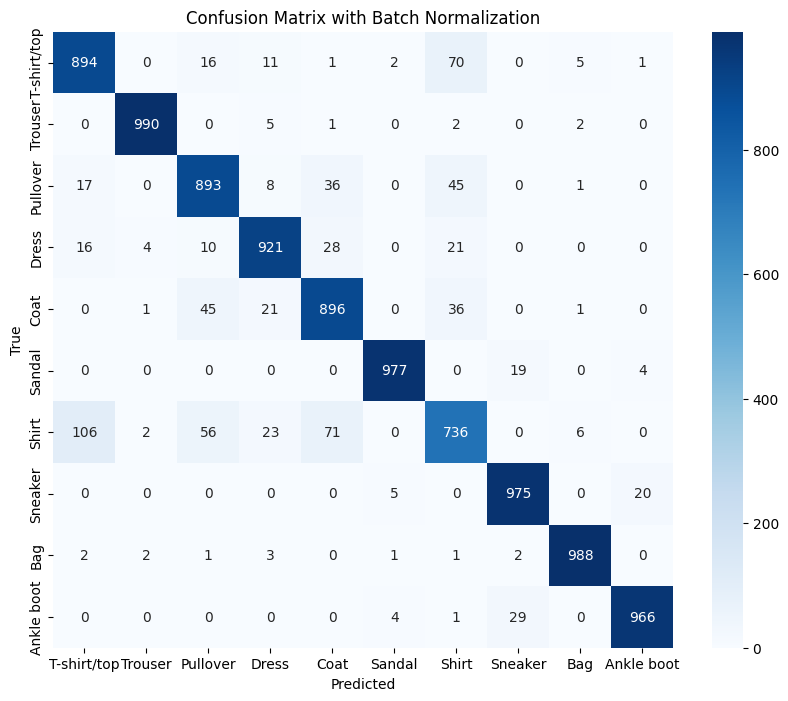


Per-class Accuracies for Model with Batch Normalization:
T-shirt/top : 89.40%
Trouser     : 99.00%
Pullover    : 89.30%
Dress       : 92.10%
Coat        : 89.60%
Sandal      : 97.70%
Shirt       : 73.60%
Sneaker     : 97.50%
Bag         : 98.80%
Ankle boot  : 96.60%


In [16]:
# Evaluate the model with Batch Normalization
labels_bn, preds_bn = evaluate_model(model_bn, test_loader, device)

print("\nClassification Report for Model with Batch Normalization:")
print(classification_report(labels_bn, preds_bn, target_names=test_data.classes))

cm_bn = confusion_matrix(labels_bn, preds_bn)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_bn, annot=True, fmt='d', cmap='Blues',
            xticklabels=test_data.classes, yticklabels=test_data.classes)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix with Batch Normalization')
plt.show()

class_accuracies_bn = 100 * cm_bn.diagonal() / cm_bn.sum(axis=1)

print("\nPer-class Accuracies for Model with Batch Normalization:")
for i, class_name in enumerate(test_data.classes):
    print(f"{class_name:<12}: {class_accuracies_bn[i]:.2f}%")

### <font color='red'>Visualizing Results with Batch Normalization</font>

Visualize the training curves, predictions, and misclassified examples for the model with Batch Normalization.

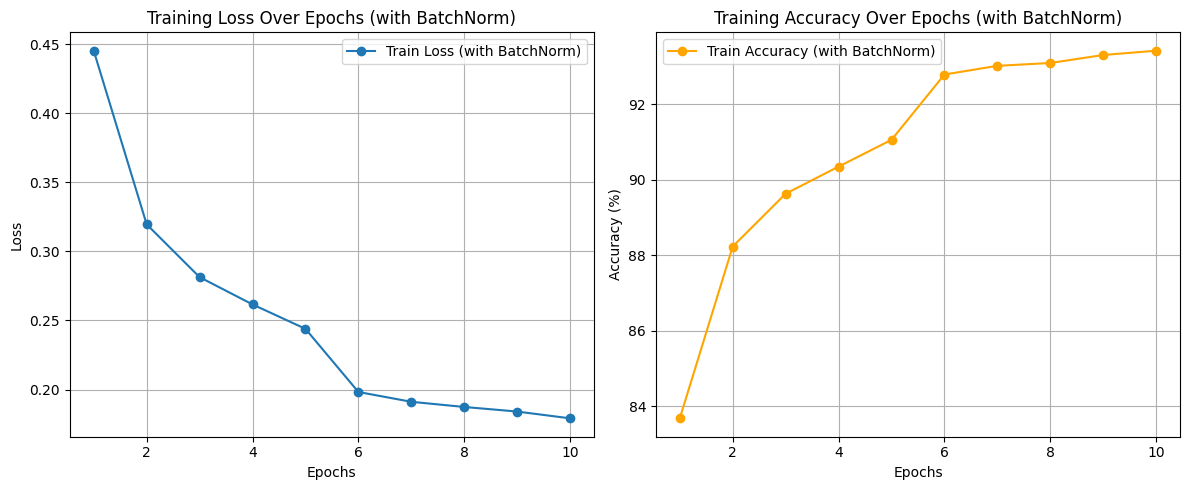

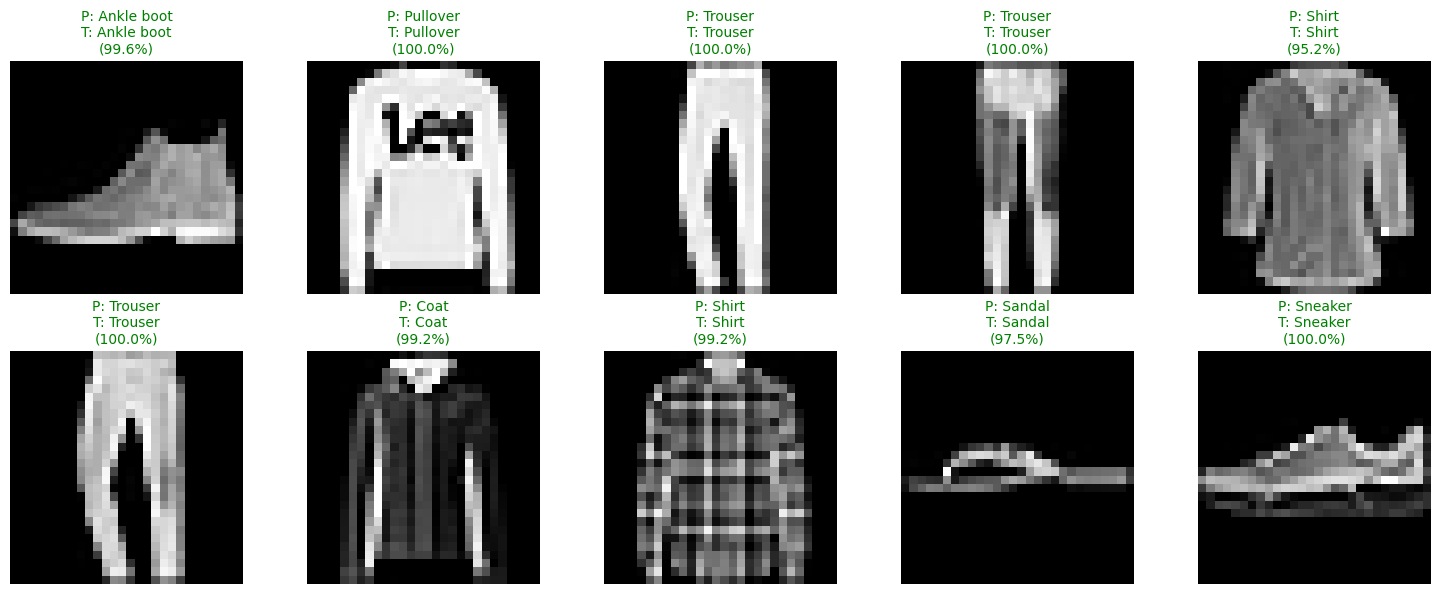

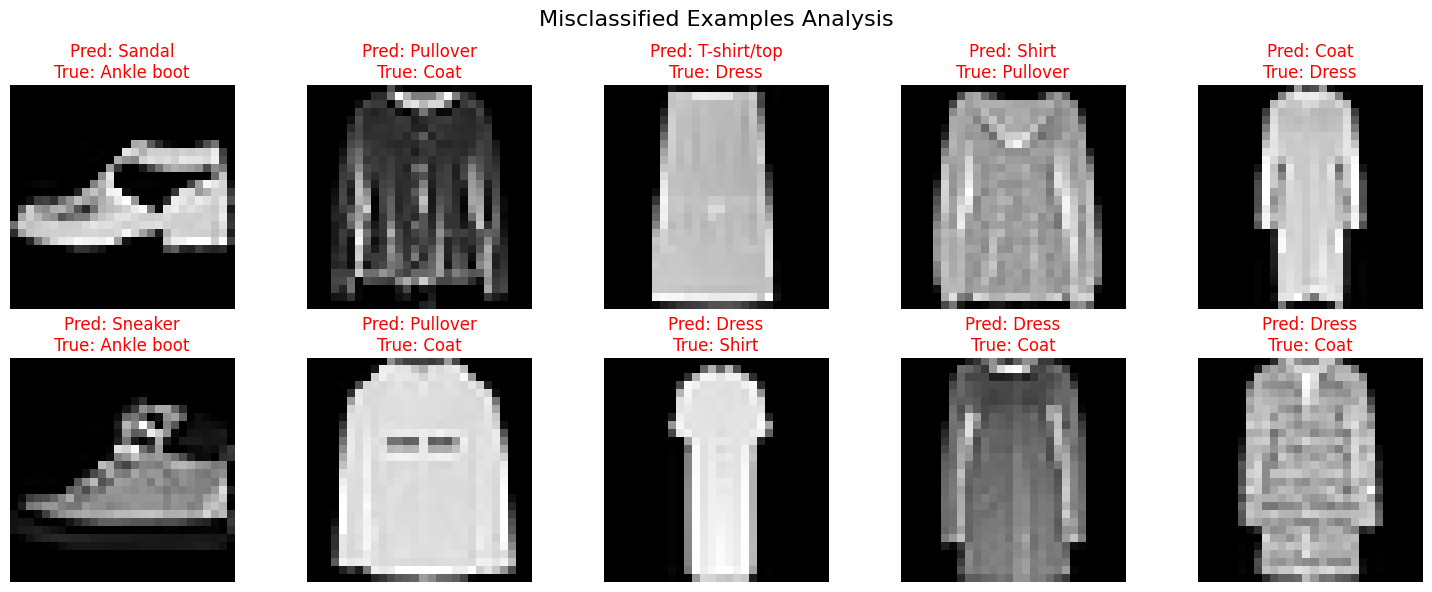

In [17]:
# Plot training loss and accuracy curves for the Batch Normalization model
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(range(1, len(train_history_bn['loss']) + 1), train_history_bn['loss'], marker='o', label='Train Loss (with BatchNorm)')
plt.title('Training Loss Over Epochs (with BatchNorm)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(range(1, len(train_history_bn['accuracy']) + 1), train_history_bn['accuracy'], marker='o', color='orange', label='Train Accuracy (with BatchNorm)')
plt.title('Training Accuracy Over Epochs (with BatchNorm)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

# Visualize predictions for the Batch Normalization model
visualize_predictions(model_bn, test_loader, device)

# Analyze misclassified examples for the Batch Normalization model
visualize_errors(model_bn, test_loader, device)

### <font color='red'>Analysis of Batch Normalization Improvement</font>

After incorporating Batch Normalization, we typically observe several improvements in model performance:

-   **Increased Accuracy**: Batch Normalization helps the model converge faster and often leads to higher accuracy on the test set.
-   **Training Stability**: The loss and accuracy curves tend to be smoother, indicating a more stable training process and less oscillation during early epochs.
-   **Improved Generalization**: Batch Normalization acts as a form of regularization, which can help the model generalize better to unseen data and reduce the risk of overfitting.
-   **Faster Convergence**: Models with Batch Normalization often reach optimal performance more quickly.

By comparing the evaluation results of the original model with those of the Batch Normalization model, we can quantify these improvements. For example, examine the final test accuracy and per-class accuracies for any significant changes.

## 📝 Evaluation Criteria

Your homework will be evaluated based on:

1. **Implementation Correctness (40%)**
   - Proper neural network implementation
   - Correct data loading and preprocessing
   - Working training loop with appropriate loss calculation

2. **Model Performance (30%)**
   - Model trains without errors
   - Reasonable accuracy on test set (>=70% expected)
   - Proper loss convergence during training

3. **Code Quality (20%)**
   - Clean, readable code with comments
   - Proper tensor handling and device management
   - Efficient implementation(No uneeded for loops, or not checking for GPU)

4. **Visualization and Analysis (10%)**
   - Clear training curves and result visualization
   - Meaningful analysis of model performance
   - Understanding of classification results